<a href="https://colab.research.google.com/github/celeron550/NER-ED2/blob/main/AED2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instala o Whisper e o ffmpeg (necessário para áudio)
!pip install openai-whisper
!apt install ffmpeg

# Monta o seu Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 48.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=b117f23080ff51dc6d70868ac8d7ea9ee32296462b7a42002d103dcf5da376f3
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [2]:
!pip install spacy
# Se seus vídeos forem em inglês (comum para F1):
!python -m spacy download en_core_web_sm
# Se forem em português:
!python -m spacy download pt_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 114.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 93.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


TRATAMENTO DOS DADOS

In [5]:
import spacy
import networkx as nx
import matplotlib.pyplot as plt
import os
import re
nlp = spacy.load("en_core_web_sm")


whitelist = ["Nigel Stepney", "Mike Coughlan", "Fernando Alonso", "Ron Dennis",
             "Lewis Hamilton", "Ferrari", "McLaren", "FIA", "Honda", "Renault"]
mapeamento_nomes = {
    "Nigel Stepney": "Nigel Stepney",
    "Stepney": "Nigel Stepney",
    "Mike Coughlan": "Mike Coughlan",
    "Coughlan": "Mike Coughlan",
    "Fernando Alonso": "Alonso",
    "Alonso": "Alonso",
    "Pedro de la Rosa": "De la Rosa",
    "Ron Dennis": "Ron Dennis",
    "Lewis Hamilton": "Hamilton",
    "Jean Todt": "Jean Todt",
    "Scuderia Ferrari": "Ferrari",
    "McLaren Mercedes": "McLaren",
    "FIA": "FIA",
    "WMSC": "FIA",
    "780-page dossier": "Dossiê",
    "Honda": "Honda",
    "Felipe Massa": "Felipe Massa",
    "Kimi Raikkonen": "Kimi Raikkonen"
}

mapeamento_nomes.update({
    "Max Mosley": "Max Mosley",
    "Mosley": "Max Mosley",
    "Bernie Ecclestone": "Bernie Ecclestone",
    "Bernie": "Bernie Ecclestone",
    "Flavio Briatore": "Flavio Briatore",
    "Ross Brawn": "Ross Brawn",
    "Luca di Montezemolo": "Montezemolo",
    "Woking": "McLaren (Woking)",
    "Maranello": "Ferrari (Maranello)",
    "Dossier": "Dossiê",
    "780 pages": "Dossiê"
})

whitelist_estrita = mapeamento_nomes.keys()
G = nx.Graph()

merged_txt = "merged_transcripts_v2.txt"
with open(merged_txt, 'r', encoding='utf-8') as f:
  texto_completo = f.read()

doc = nlp(texto_completo)
nlp.max_length = len(texto_completo) + 1000

for sent in doc.sents:
  ents_na_frase = []
  for termo in whitelist_estrita:
    if re.search(rf'\b{re.escape(termo)}\b', sent.text, re.IGNORECASE):
      ents_na_frase.append(mapeamento_nomes[termo])

  ents_na_frase = list(set(ents_na_frase))
  for i in range(len(ents_na_frase)):
    for j in range(i+1, len(ents_na_frase)):
      u, v = ents_na_frase[i], ents_na_frase[j]
      if G.has_edge(u,v):
        G[u][v]['weight'] += 1
      else:
        G.add_edge(u, v, weight=1)

nx.write_graphml(G, "grafos/spygate_graph_en_sentenca.graphml")

VISUALIZAR OS DADOS

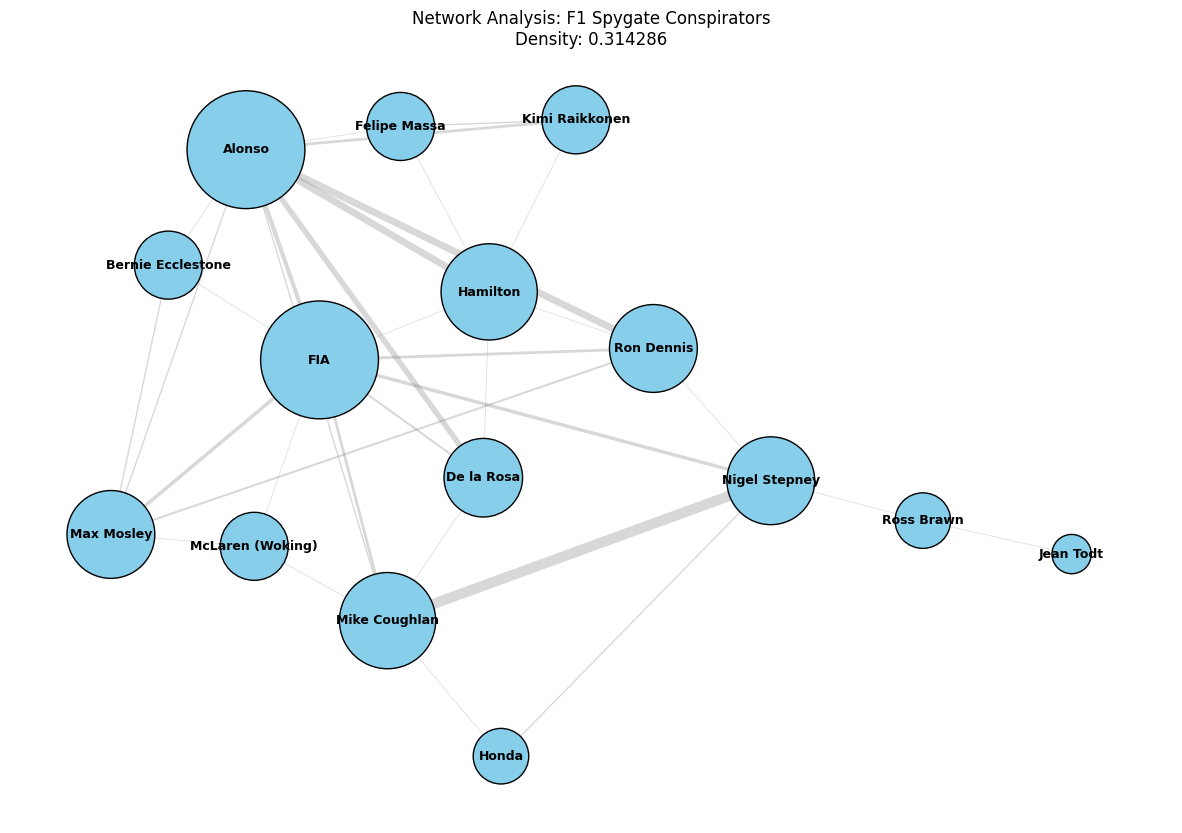

In [6]:
# --- Visualização com Métricas da Aula 03 ---
plt.figure(figsize=(15, 10))
# Usar o layout Kamada-Kawai ajuda a evitar a sobreposição de nomes
pos = nx.kamada_kawai_layout(G)


graus = dict(G.degree())

nx.draw_networkx_nodes(G, pos, node_size=[v * 800 for v in graus.values()], node_color='skyblue', edgecolors='black')
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray', width=[G[u][v]['weight']*0.5 for u, v in G.edges()])
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

plt.title(f"Network Analysis: F1 Spygate Conspirators\nDensity: {nx.density(G):.6f}")
plt.axis('off')
plt.show()

***HISTOGRAMA DOS DADOS POR SENTENÇA***

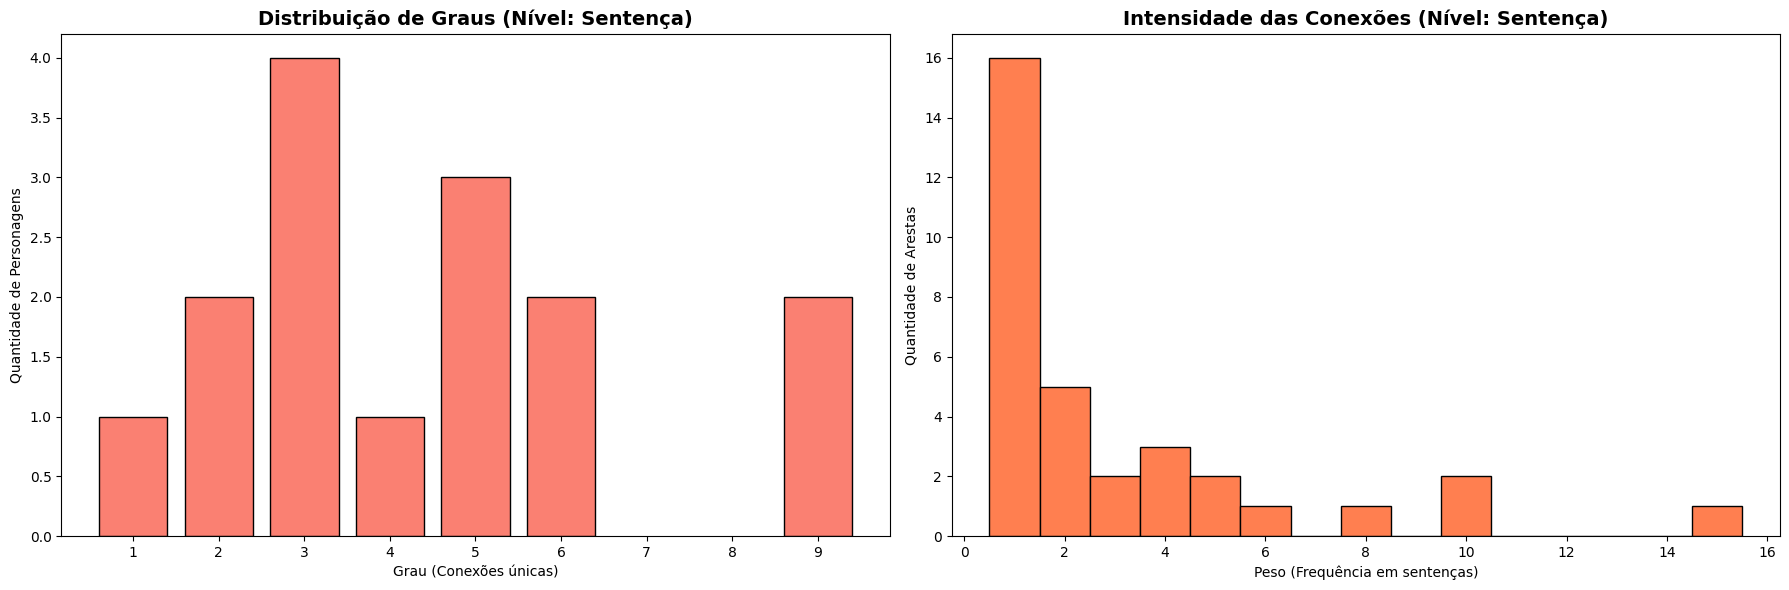

In [7]:
import pandas as pd
import collections
import numpy as np

# --- 1. GERAÇÃO DOS HISTOGRAMAS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Histograma de Graus
graus_sent = [d for n, d in G.degree()]
contagem_graus = collections.Counter(graus_sent)
deg, cnt = zip(*contagem_graus.items())

ax1.bar(deg, cnt, width=0.8, color='salmon', edgecolor='black') # Cor salmão para diferenciar do de parágrafo
ax1.set_title("Distribuição de Graus (Nível: Sentença)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Grau (Conexões únicas)")
ax1.set_ylabel("Quantidade de Personagens")
ax1.set_xticks(range(int(min(graus_sent)), int(max(graus_sent)) + 1))

# Histograma de Pesos
pesos_sent = [d['weight'] for u, v, d in G.edges(data=True)]
ax2.hist(pesos_sent, bins=range(int(min(pesos_sent)), int(max(pesos_sent)) + 2), color='coral', edgecolor='black', align='left')
ax2.set_title("Intensidade das Conexões (Nível: Sentença)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Peso (Frequência em sentenças)")
ax2.set_ylabel("Quantidade de Arestas")

plt.tight_layout()
plt.show()

In [ ]:
# nx.write_gexf(G, "spygate_graph.gexf")

***CALCULO DAS METRICAS POR SENTENÇA***

In [8]:
import pandas as pd
import collections
import numpy as np

degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G)
closeness_cent = nx.closeness_centrality(G)

metrics_df = pd.DataFrame({
    'Personagem': list(degree_cent.keys()),
    'Centralidade de Grau': list(degree_cent.values()),
    'Intermediação (Betweenness)': list(betweenness_cent.values()),
    'Proximidade (Closeness)': list(closeness_cent.values())
})

# Ranking dos 5 principais por Intermediação
top_5_sentenca = metrics_df.sort_values(by='Intermediação (Betweenness)', ascending=False).head(5)

print("\n--- ESTATÍSTICAS GLOBAIS (SENTENÇA) ---")
print(f"Nós: {G.number_of_nodes()} | Arestas: {G.number_of_edges()}")
print(f"Densidade: {nx.density(G):.4f}")

print("\n--- TOP 5 ATORES (RANKING DE INTERMEDIAÇÃO - SENTENÇA) ---")
print(top_5_sentenca.to_string(index=False))


--- ESTATÍSTICAS GLOBAIS (SENTENÇA) ---
Nós: 15 | Arestas: 33
Densidade: 0.3143

--- TOP 5 ATORES (RANKING DE INTERMEDIAÇÃO - SENTENÇA) ---
   Personagem  Centralidade de Grau  Intermediação (Betweenness)  Proximidade (Closeness)
Nigel Stepney              0.357143                     0.296337                 0.560000
          FIA              0.642857                     0.238462                 0.700000
       Alonso              0.642857                     0.228938                 0.636364
Mike Coughlan              0.428571                     0.152747                 0.608696
   Ross Brawn              0.142857                     0.142857                 0.388889


In [ ]:
!python -m spacy download pt_core_news_md

import spacy
nlp = spacy.load("pt_core_news_md")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 20.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


TESTE POR PARAGRAFO


In [9]:
import spacy
import networkx as nx
import matplotlib.pyplot as plt
import os
import re

# Carregamos o nlp apenas se precisar de outras funções do spacy,
# mas para parágrafos usaremos split direto na string.
nlp = spacy.load("pt_core_news_sm")

whitelist = ["Nigel Stepney", "Mike Coughlan", "Fernando Alonso", "Ron Dennis",
             "Lewis Hamilton", "Ferrari", "McLaren", "FIA", "Honda", "Renault"]

mapeamento_nomes = {
    "Nigel Stepney": "Nigel Stepney",
    "Stepney": "Nigel Stepney",
    "Mike Coughlan": "Mike Coughlan",
    "Coughlan": "Mike Coughlan",
    "Fernando Alonso": "Alonso",
    "Alonso": "Alonso",
    "Pedro de la Rosa": "De la Rosa",
    "Ron Dennis": "Ron Dennis",
    "Lewis Hamilton": "Hamilton",
    "Jean Todt": "Jean Todt",
    "Scuderia Ferrari": "Ferrari",
    "McLaren Mercedes": "McLaren",
    "FIA": "FIA",
    "WMSC": "FIA",
    "780-page dossier": "Dossiê",
    "Honda": "Honda",
    "Felipe Massa": "Felipe Massa",
    "Kimi Raikkonen": "Kimi Raikkonen"
}

mapeamento_nomes.update({
    "Max Mosley": "Max Mosley",
    "Mosley": "Max Mosley",
    "Bernie Ecclestone": "Bernie Ecclestone",
    "Bernie": "Bernie Ecclestone",
    "Flavio Briatore": "Flavio Briatore",
    "Ross Brawn": "Ross Brawn",
    "Luca di Montezemolo": "Montezemolo",
    "Woking": "McLaren (Woking)",
    "Maranello": "Ferrari (Maranello)",
    "Dossier": "Dossiê",
    "780 pages": "Dossiê"
})

whitelist_estrita = mapeamento_nomes.keys()
G_pt_paragrafo = nx.Graph()

merged_txt = "merged_transcripts_v2.txt"
with open(merged_txt, 'r', encoding='utf-8') as f:
    texto_completo = f.read()

# Divisão por parágrafos (remove espaços em branco e parágrafos vazios)
paragrafos = [p for p in texto_completo.split('\n') if p.strip()]

for paragrafo in paragrafos:
    ents_no_paragrafo = []
    for termo in whitelist_estrita:
        # Busca o termo dentro do bloco do parágrafo
        if re.search(rf'\b{re.escape(termo)}\b', paragrafo, re.IGNORECASE):
            ents_no_paragrafo.append(mapeamento_nomes[termo])

    # Remove duplicatas de nomes que mapeiam para a mesma entidade no mesmo parágrafo
    ents_no_paragrafo = list(set(ents_no_paragrafo))

    # Criação das arestas baseada na co-ocorrência no parágrafo
    for i in range(len(ents_no_paragrafo)):
        for j in range(i+1, len(ents_no_paragrafo)):
            u, v = ents_no_paragrafo[i], ents_no_paragrafo[j]
            if G_pt_paragrafo.has_edge(u,v):
                G_pt_paragrafo[u][v]['weight'] += 1
            else:
                G_pt_paragrafo.add_edge(u, v, weight=1)


output_path = "grafos/spygate_graph_pt-paragrafos.graphml"
nx.write_graphml(G_pt_paragrafo, output_path)

***VISUALIZAR OS DADOS***

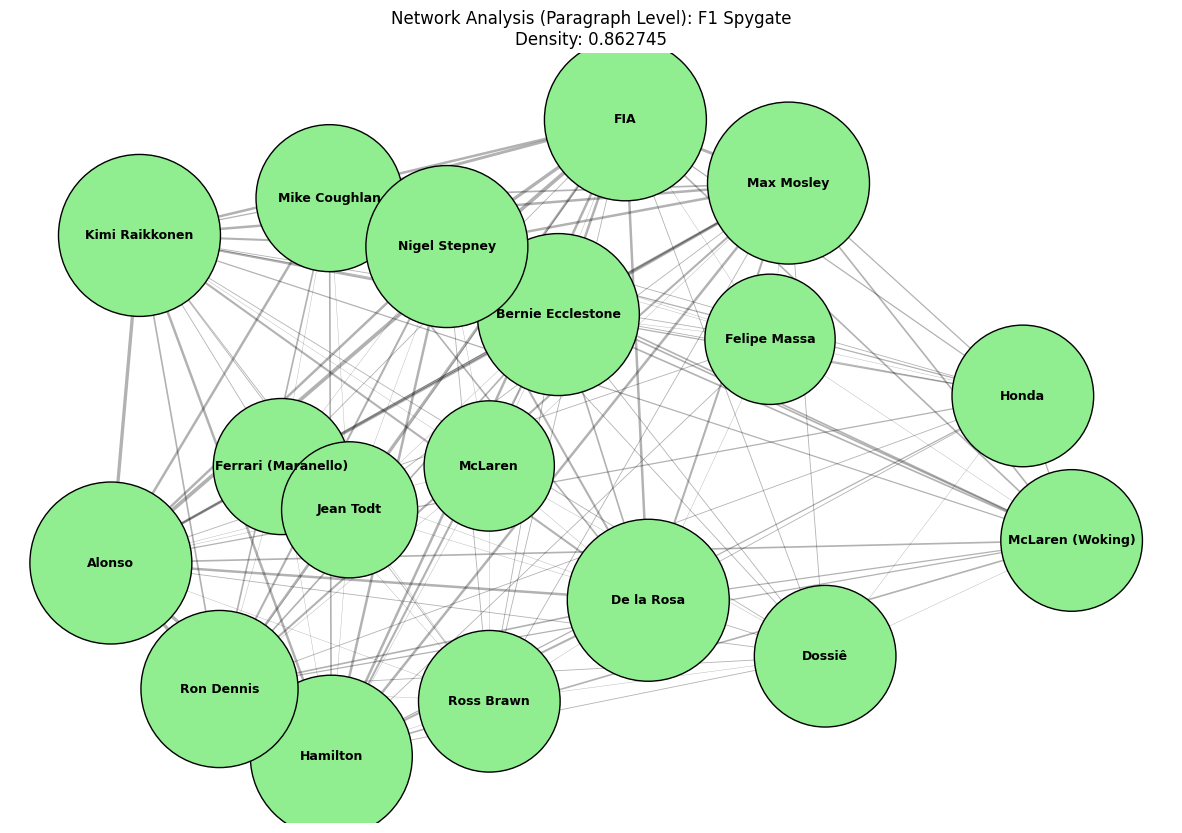

In [10]:
# Visualização
plt.figure(figsize=(15, 10))
pos = nx.kamada_kawai_layout(G_pt_paragrafo)
graus = dict(G_pt_paragrafo.degree())

nx.draw_networkx_nodes(G_pt_paragrafo, pos,
                       node_size=[v * 800 for v in graus.values()],
                       node_color='lightgreen',
                       edgecolors='black')

nx.draw_networkx_edges(G_pt_paragrafo, pos, alpha=0.3,
                       edge_color='black',
                       width=[G_pt_paragrafo[u][v]['weight']*0.3 for u, v in G_pt_paragrafo.edges()])

nx.draw_networkx_labels(G_pt_paragrafo, pos, font_size=9, font_weight="bold")

plt.title(f"Network Analysis (Paragraph Level): F1 Spygate\nDensity: {nx.density(G_pt_paragrafo):.6f}")
plt.axis('off')
plt.show()

***HISTOGRAMA DOS DADOS POR PARÁGRAFOS***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


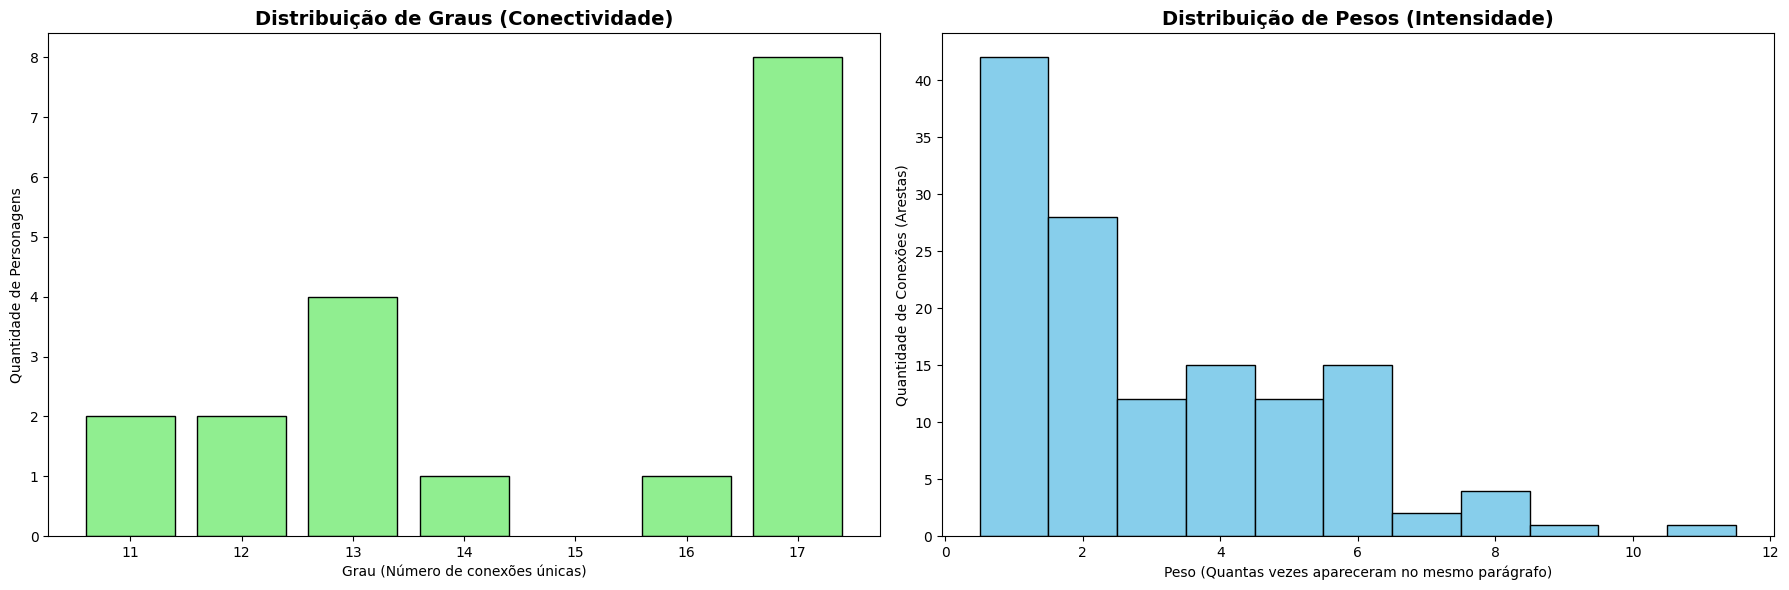

In [11]:
import numpy as np
import collections

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# DISTRIBUIÇÃO DE GRAUS
# quantos vizinhos diferentes cada personagem tem
graus = [d for n, d in G_pt_paragrafo.degree()]
contagem_graus = collections.Counter(graus)
deg, cnt = zip(*contagem_graus.items())

ax1.bar(deg, cnt, width=0.8, color='lightgreen', edgecolor='black')
ax1.set_title("Distribuição de Graus (Conectividade)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Grau (Número de conexões únicas)")
ax1.set_ylabel("Quantidade de Personagens")
ax1.set_xticks(range(min(graus), max(graus) + 1))

# PESO DAS ARESTAS
# frequência das interações nos parágrafos
pesos = [d['weight'] for u, v, d in G_pt_paragrafo.edges(data=True)]

ax2.hist(pesos, bins=range(min(pesos), max(pesos) + 2), color='skyblue', edgecolor='black', align='left')
ax2.set_title("Distribuição de Pesos (Intensidade)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Peso (Quantas vezes apareceram no mesmo parágrafo)")
ax2.set_ylabel("Quantidade de Conexões (Arestas)")

plt.tight_layout()
plt.show()

In [ ]:
centralidade = nx.betweenness_centrality(G_pt_paragrafo)
top_5 = sorted(centralidade.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 Pontes (Betweenness):", top_5)

Top 5 Pontes (Betweenness): [('Bernie Ecclestone', 0.015853386809269163), ('De la Rosa', 0.015853386809269163), ('Nigel Stepney', 0.015853386809269163), ('Max Mosley', 0.015853386809269163), ('FIA', 0.015853386809269163)]


***CALCULO DE METRICAS POR PARAGRAFO***

In [12]:
import pandas as pd

# 1. Cálculo das Métricas de Centralidade
# Remove conexões que só aconteceram 1 vez (limpa o ruído)
arestas_fracas = [(u, v) for u, v, d in G_pt_paragrafo.edges(data=True) if d['weight'] <= 1]
G_pt_paragrafo.remove_edges_from(arestas_fracas)

# Agora recalcule as centralidades
degree_cent = nx.degree_centrality(G_pt_paragrafo)
betweenness_cent = nx.betweenness_centrality(G_pt_paragrafo)
closeness_cent = nx.closeness_centrality(G_pt_paragrafo)

# 2. Criar um DataFrame para facilitar a visualização e o print para o relatório
metrics_df = pd.DataFrame({
    'Personagem': list(degree_cent.keys()),
    'Centralidade de Grau': list(degree_cent.values()),
    'Intermediação (Betweenness)': list(betweenness_cent.values()),
    'Proximidade (Closeness)': list(closeness_cent.values())
})

# 3. Formatação e Ranking (Top 5 por Intermediação - quem controla a informação)
top_5_rank = metrics_df.sort_values(by='Intermediação (Betweenness)', ascending=False).head(5)

# 4. Estatísticas Globais da Rede
print("--- ESTATÍSTICAS GLOBAIS DA REDE ---")
print(f"Número de Nós: {G_pt_paragrafo.number_of_nodes()}")
print(f"Número de Arestas: {G_pt_paragrafo.number_of_edges()}")
print(f"Densidade: {nx.density(G_pt_paragrafo):.4f}")
print(f"Transitividade (Clusterização Global): {nx.transitivity(G_pt_paragrafo):.4f}")

if nx.is_connected(G_pt_paragrafo):
    print(f"Diâmetro da Rede: {nx.diameter(G_pt_paragrafo)}")
else:
    print("A rede é desconectada (existem ilhas de nós).")

print("\n--- TOP 5 ATORES (RANKING DE INTERMEDIAÇÃO) ---")
print(top_5_rank.to_string(index=False))

--- ESTATÍSTICAS GLOBAIS DA REDE ---
Número de Nós: 18
Número de Arestas: 90
Densidade: 0.5882
Transitividade (Clusterização Global): 0.8340
A rede é desconectada (existem ilhas de nós).

--- TOP 5 ATORES (RANKING DE INTERMEDIAÇÃO) ---
    Personagem  Centralidade de Grau  Intermediação (Betweenness)  Proximidade (Closeness)
Kimi Raikkonen              0.941176                     0.114706                 0.941176
    Max Mosley              0.882353                     0.068137                 0.885813
           FIA              0.882353                     0.068137                 0.885813
      Hamilton              0.764706                     0.026961                 0.792570
        Alonso              0.764706                     0.026961                 0.792570


***EXPORTANDO PRO GEPHI***

In [ ]:
# Exportando a versão por SENTENÇA
nx.write_gexf(G, "grafos/spygate_sentenca.gexf")

# Exportando a versão por PARÁGRAFO
nx.write_gexf(G_pt_paragrafo, "grafos/spygate_paragrafo.gexf")